# LLM Plan Optimizer — oh-my-openagent soup

Finds the cheapest combination of plans (subscriptions + token APIs) that covers every agent role.

All model data, skill profiles, and plan definitions live in **`models.json`**.  
Agent roles and workload parameters live in **`config.json`** (loaded by Cell 3).  

**Execution order matters:** the validator in Cell 1 must pass before Cell 2+ can run.

---
```
models.json  ──►  Cell 1: Validate  ──►  Cell 2: Load & index
                                    ──►  Cell 3: Configure agents + budget
                                    ──►  Cell 4: Run optimizer (brute-force)
                                    ──►  Cell 5: Results table
                                    ──►  Cell 6: Token volume reality check
```

## Cell 1 — Validate `models.json`
Asserts model key format, mandatory skills, plan references, pricing fields.  
**Hard-stops on any violation** — fix the JSON and re-run before continuing.

In [15]:
import json, re, sys
from pathlib import Path

MODELS_JSON_PATH = Path("models.json")  # ← change if needed

# ─── Canonical validator (mirrors validate_models.py exactly) ─────────────────

def validate(path: Path = MODELS_JSON_PATH, silent: bool = False) -> dict:
    raw = Path(path).read_text()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError as e:
        raise AssertionError(f"INVALID JSON in '{path}': {e}")

    skills_def  = data["skills"]
    models_def  = data["models"]
    plans_def   = data["plans"]

    mandatory_skills = {k for k, v in skills_def.items() if v.get("mandatory")}

    # ── 1. No legacy optimizer_id fields ──────────────────────────────────────
    for key, model in models_def.items():
        assert "optimizer_id" not in model, (
            f"LEGACY FIELD 'optimizer_id' found in model '{key}'.\n"
            f"  The model key ('{key}') IS the id now — remove 'optimizer_id'."
        )

    # ── 2. No api_rate on models (it belongs on the plan) ─────────────────────
    for key, model in models_def.items():
        assert "api_rate" not in model, (
            f"LEGACY FIELD 'api_rate' found in model '{key}'.\n"
            f"  Pricing belongs on the plan, not the model.\n"
            f"  Remove 'api_rate' from the model and put input_usd_per_m / output_usd_per_m\n"
            f"  on each model entry inside the relevant per_token plan."
        )

    # ── 3. Model key format: provider/name ────────────────────────────────────
    KEY_RE = re.compile(r"^[a-z0-9_-]+/[a-z0-9_.\-]+$")
    for key in models_def:
        assert KEY_RE.match(key), (
            f"BAD MODEL KEY FORMAT: '{key}'.\n"
            f"  Must be 'provider/name' — lowercase alphanumeric, hyphens, underscores, dots.\n"
            f"  Example: 'anthropic/claude-opus-4-7'"
        )

    # ── 4. Mandatory skills + score range ─────────────────────────────────────
    for key, model in models_def.items():
        skills = model.get("skills", {})
        for s in mandatory_skills:
            assert s in skills, (
                f"MISSING MANDATORY SKILL '{s}' in model '{key}'.\n"
                f"  Model has: {list(skills.keys())}\n"
                f"  Fix: add '{s}': <0–10> to the skills dict."
            )
        for sk, score in skills.items():
            assert sk in skills_def, (
                f"UNKNOWN SKILL '{sk}' in model '{key}'.\n"
                f"  Known skills: {list(skills_def.keys())}\n"
                f"  Fix: add '{sk}' to the top-level skills definition, or remove it."
            )
            assert isinstance(score, (int, float)) and 0 <= score <= 10, (
                f"SKILL SCORE OUT OF RANGE: '{sk}' = {score!r} in model '{key}'.\n"
                f"  Fix: score must be a number in [0, 10]."
            )

    # ── 5. benchmarks.swe_verified present on every model ─────────────────────
    for key, model in models_def.items():
        assert "benchmarks" in model, (
            f"MISSING 'benchmarks' block in model '{key}'.\n"
            f"  Fix: add 'benchmarks': {{'swe_verified': <float>, 'swe_rank': <int>}}"
        )
        assert "swe_verified" in model["benchmarks"], (
            f"MISSING 'benchmarks.swe_verified' in model '{key}'."
        )

    # ── 6. Plan types ──────────────────────────────────────────────────────────
    valid_types = {"recurrent", "per_token"}
    for plan in plans_def:
        pid = plan.get("id", "<no id>")
        assert "type" in plan, f"PLAN '{pid}' missing 'type' field."
        assert plan["type"] in valid_types, (
            f"INVALID PLAN TYPE '{plan['type']}' in plan '{pid}'.\n"
            f"  Valid: {valid_types}"
        )

    # ── 7. Plan model references resolve ──────────────────────────────────────
    known_keys = set(models_def.keys())
    for plan in plans_def:
        pid         = plan.get("id", "<no id>")
        plan_models = plan.get("models", {})
        assert isinstance(plan_models, dict) and len(plan_models) > 0, (
            f"PLAN '{pid}' has no 'models' dict or it is empty."
        )
        for model_key in plan_models:
            assert model_key in known_keys, (
                f"UNKNOWN MODEL REFERENCE '{model_key}' in plan '{pid}'.\n"
                f"  Known models:\n"
                + "\n".join(f"    {k}" for k in sorted(known_keys))
                + f"\n  Fix: correct the key to match exactly one of the above."
            )

    # ── 8. Recurrent plans: request_weight on each model ─────────────────────
    for plan in plans_def:
        pid = plan["id"]
        if plan["type"] == "recurrent":
            for model_key, mdata in plan["models"].items():
                assert "request_weight" in mdata, (
                    f"MISSING 'request_weight' for '{model_key}' in recurrent plan '{pid}'.\n"
                    f"  request_weight = relative token-cost multiplier (gpt-5-4 = 1.0 baseline).\n"
                    f"  Fix: add 'request_weight': <float> to the model entry."
                )
                rw = mdata["request_weight"]
                assert isinstance(rw, (int, float)) and rw >= 0, (
                    f"INVALID request_weight {rw!r} for '{model_key}' in plan '{pid}'.\n"
                    f"  Fix: must be a non-negative number (0.0 = free/unlimited on paid plan)."
                )

    # ── 9. Per-token pure-API plans: pricing on each model entry ──────────────
    for plan in plans_def:
        pid = plan["id"]
        if plan["type"] == "per_token" and not plan.get("credit_pool_usd"):
            for model_key, mdata in plan["models"].items():
                for field in ("input_usd_per_m", "output_usd_per_m"):
                    assert field in mdata, (
                        f"MISSING '{field}' for '{model_key}' in per_token plan '{pid}'.\n"
                        f"  Fix: add 'input_usd_per_m' and 'output_usd_per_m' to the model entry."
                    )

    # ── 10. No duplicate plan ids ───────────────────────────────────────────────
    seen: set = set()
    for plan in plans_def:
        pid = plan["id"]
        assert pid not in seen, (
            f"DUPLICATE PLAN ID '{pid}'.\n"
            f"  Fix: each plan must have a unique 'id'."
        )
        seen.add(pid)

    if not silent:
        _print_summary(data, mandatory_skills)

    return data


def _print_summary(data: dict, mandatory_skills: set):
    models_def = data["models"]
    plans_def  = data["plans"]
    skills_def = data["skills"]

    print(f"✓  models.json valid — "
          f"{len(models_def)} models · {len(plans_def)} plans · {len(skills_def)} skill dims")
    print(f"   Mandatory skills: {sorted(mandatory_skills)}\n")

    # Model table
    W = 36
    print(f"   {'Model key':<{W}}  {'SWE%':>5}  vibe  hard  agent  notes")
    print(f"   {'─'*W}  {'─'*5}  {'─'*4}  {'─'*4}  {'─'*5}  {'─'*30}")
    for key, m in models_def.items():
        sk    = m.get("skills", {})
        bm    = m.get("benchmarks", {})
        swe   = bm.get("swe_verified", 0)
        swe_s = f"{swe:.0f}%" if swe else "—"
        vibe  = sk.get("vibe", "—")
        hard  = sk.get("hardworkingness", "—")
        agent = sk.get("agentic", "—")
        note  = m.get("notes", "")[:35]
        print(f"   {key:<{W}}  {swe_s:>5}  {vibe:<4}  {hard:<4}  {agent:<5}  {note}")
    print()

    # Plan table
    print(f"   {'Plan id':<22}  {'type':<10}  {'$/mo':>6}  {'models'}")
    print(f"   {'─'*22}  {'─'*10}  {'─'*6}  {'─'*40}")
    for plan in plans_def:
        mlist = ", ".join(plan["models"].keys())
        pool  = f" (pool ${plan['credit_pool_usd']})" if plan.get("credit_pool_usd") else ""
        print(f"   {plan['id']:<22}  {plan['type']:<10}  "
              f"${plan['cost_usd_per_month']:>5.2f}  {mlist[:60]}{pool}")
    print()

# ─── Run ──────────────────────────────────────────────────────────────────────
try:
    _raw_data = validate(MODELS_JSON_PATH)
except AssertionError as e:
    print(f"\n{'═'*64}\n  VALIDATION FAILED — fix models.json and re-run\n{'═'*64}\n\n{e}\n")
    raise SystemExit(1)  # blocks further cells in "Run All"


✓  models.json valid — 15 models · 34 plans · 9 skill dims
   Mandatory skills: ['agentic', 'hardworkingness', 'vibe']

   Model key                              SWE%  vibe  hard  agent  notes
   ────────────────────────────────────  ─────  ────  ────  ─────  ──────────────────────────────
   anthropic/claude-opus-4-7               82%  9     10    9.75   Best overall. Highest SWE-bench (82
   anthropic/claude-opus-4-6               78%  10    9.75  9.5    Previous gen Opus. Slightly below 4
   anthropic/claude-sonnet-4-6             77%  7.5   8     7.5    Balanced mid-tier. Good for tasks w
   anthropic/claude-haiku-4-5              67%  2     2.75  5.5    Fast and cheap. Cuts corners on com
   openai/gpt-5-4                          78%  8     9     9      Workhouse specialist. Best-in-class
   openai/gpt-5-4-mini                     73%  5.5   6     7      Cheap and fast. Good for structured
   openai/gpt-5-mini                       56%  2.5   2.5   5      Cheapest and fast. Good 

## Cell 2 — Load & index `models.json`
Builds typed Python objects from the validated JSON.  
Model keys (`provider/name`) are used throughout — no aliasing.

In [16]:
import itertools, math
from dataclasses import dataclass, field
from typing import Optional

# ─── Data classes ─────────────────────────────────────────────────────────────

@dataclass
class ModelInfo:
    key: str                    # "provider/name" — canonical id
    display_name: str
    skills: dict[str, float]
    swe_verified: float
    swe_rank: int
    swe_pro: Optional[float]
    notes: str = ""
    # NOTE: no rate fields here — pricing lives on the plan's model entry


@dataclass
class PlanInfo:
    id: str
    display_name: str
    provider: str
    plan_type: str              # "recurrent" | "per_token"
    cost_per_month: float
    model_keys: set[str]        # which models this plan unlocks
    # Recurrent: shared token pool
    tokens_per_day: Optional[float] = None
    requests_per_month: Optional[int] = None
    # Per-token (Cursor): $ credit pool
    credit_pool_usd: Optional[float] = None
    # Per-model data dict (request_weight OR per-token pricing, depending on type)
    model_data: dict = field(default_factory=dict)
    notes: str = ""
    bills_subagents: bool = True   # False = plan does not charge for internal subagent calls
    # request_multiplier: how many plan "requests" one chat message consumes on average.
    # Copilot/GLM-devpack = 1 (bills 1 per top-level message, ignores tool calls).
    # Alibaba = ~25 (bills each model invocation; agentic task ≈ 15-30 tool calls).
    request_multiplier: int = 1
    deactivated: bool = False   # True = plan exists but cannot be purchased; skip in optimizer
    # primary_models: ordered list of model keys that are the "home" models for this plan.
    # Used by the optimizer to prefer plan-native assignments (e.g. GLM devpack → GLM-5.1 first).
    # If empty, all plan models are treated equally.
    primary_models: list = field(default_factory=list)

    @property
    def is_token_api(self) -> bool:
        return self.plan_type == "per_token" and self.credit_pool_usd is None

    @property
    def is_cursor(self) -> bool:
        return self.plan_type == "per_token" and self.credit_pool_usd is not None

    def blended_rate(self, model_key: str, input_ratio: float = 0.75) -> float:
        """$/M tokens blended for a specific model in this plan (plan-level pricing)."""
        mdata = self.model_data.get(model_key, {})
        inp   = mdata.get("input_usd_per_m", 0.0)
        out   = mdata.get("output_usd_per_m", 0.0)
        cach  = mdata.get("cached_usd_per_m", inp)
        hit   = mdata.get("cache_hit_rate", 0.0)
        eff_inp = cach * hit + inp * (1 - hit) if hit else inp
        return eff_inp * input_ratio + out * (1 - input_ratio)

    def monthly_api_cost(self, model_key: str, tokens_per_day: float,
                         input_ratio: float = 0.75) -> float:
        return self.blended_rate(model_key, input_ratio) * tokens_per_day / 1e6 * 30


# ─── Build indexes ────────────────────────────────────────────────────────────

def _load(data: dict) -> tuple[dict[str, ModelInfo], list[PlanInfo]]:
    models: dict[str, ModelInfo] = {}
    for key, m in data["models"].items():
        bm = m["benchmarks"]
        models[key] = ModelInfo(
            key          = key,
            display_name = m["display_name"],
            skills       = m.get("skills", {}),
            swe_verified = bm["swe_verified"],
            swe_rank     = bm.get("swe_rank", 99),
            swe_pro      = bm.get("swe_pro"),
            notes        = m.get("notes", ""),
        )

    plans: list[PlanInfo] = []
    for p in data["plans"]:
        quota = p.get("quota", {})
        plans.append(PlanInfo(
            id                 = p["id"],
            display_name       = p["display_name"],
            provider           = p["provider"],
            plan_type          = p["type"],
            cost_per_month     = p["cost_usd_per_month"],
            model_keys         = set(p["models"].keys()),
            tokens_per_day     = quota.get("tokens_per_day"),
            requests_per_month = quota.get("requests_per_month"),
            credit_pool_usd    = p.get("credit_pool_usd"),
            model_data         = p["models"],
            notes              = p.get("notes", ""),
            bills_subagents    = p.get("bills_subagents", True),
            request_multiplier = p.get("request_multiplier", 1),
            deactivated        = p.get("deactivated", False),
            primary_models     = list(p.get("primary_models", [])),
        ))
    return models, plans


MODELS, PLANS = _load(_raw_data)

# Drop deactivated plans — they exist in models.json for reference but cannot be purchased
_deactivated = [p.id for p in PLANS if p.deactivated]
PLANS = [p for p in PLANS if not p.deactivated]
if _deactivated:
    print(f"  ⚠  Skipping {len(_deactivated)} deactivated plan(s): {_deactivated}")

print(f"Loaded {len(MODELS)} models, {len(PLANS)} plans.")
print()

# ─── Model reference table ────────────────────────────────────────────────────
# For blended rate display: find the cheapest per_token plan that lists each model
def _best_api_rate(mkey: str, plans: list[PlanInfo], input_ratio: float = 0.75) -> Optional[float]:
    rates = [
        p.blended_rate(mkey, input_ratio)
        for p in plans
        if p.is_token_api and mkey in p.model_keys and p.blended_rate(mkey, input_ratio) >= 0
    ]
    return min(rates) if rates else None

print(f"{'Key':<36} {'SWE%':>5}  {'best API $/M':>11}  {'vibe':>4}  {'hard':>4}  {'agt':>3}  Notes")
print("─" * 100)
for key, m in sorted(MODELS.items(), key=lambda x: x[1].swe_rank):
    bl    = _best_api_rate(key, PLANS)
    bl_s  = "sub-only" if bl is None else ("FREE" if bl == 0 else f"${bl:.3f}")
    swe_s = f"{m.swe_verified:.0f}%" if m.swe_verified else "—"
    pro_s = f" [Pro:{m.swe_pro}]" if m.swe_pro else ""
    sk = m.skills
    print(f"{key:<36} {swe_s:>5}  {bl_s:>11}  "
          f"{sk.get('vibe','—'):>4}  {sk.get('hardworkingness','—'):>4}  "
          f"{sk.get('agentic','—'):>3}  {m.notes[:45]}{pro_s}")


  ⚠  Skipping 1 deactivated plan(s): ['alibaba-coding-pro']
Loaded 15 models, 33 plans.

Key                                   SWE%  best API $/M  vibe  hard  agt  Notes
────────────────────────────────────────────────────────────────────────────────────────────────────
anthropic/claude-opus-4-7              82%       $6.963     9    10  9.75  Best overall. Highest SWE-bench (82%). Except
google/gemini-3-1-pro                  79%       $2.873  7.8333     7  4.5  Best creative model. Excellent at multimodal,
openai/gpt-5-4                         78%       $4.191     8     9    9  Workhouse specialist. Best-in-class for preci
anthropic/claude-opus-4-6              78%      $20.887    10  9.75  9.5  Previous gen Opus. Slightly below 4.7 on benc
anthropic/claude-sonnet-4-6            77%       $4.178   7.5     8  7.5  Balanced mid-tier. Good for tasks where Opus 
zai/glm-5-1                            76%       $1.509  7.6667   8.5  8.5  MIT open-weight. SWE-bench Pro #1 (58.4), tie [Pro

## Cell 3 — Load `config.json`
Reads `config.json` for budget, plan limits, and role definitions.  
**Edit `config.json`** — not this cell — to change your workload or budget.  

```
config.json fields:
  budget_usd          — monthly spend limit ($)
  max_plans_in_combo  — brute-force depth (default 4)
  top_n               — results to display
  roles[]             — list of agent roles:
    name                      display name
    prompts_per_week          invocations per week
    avg_input_tokens          average input size per call
    avg_output_tokens         average output size per call
    is_subagent               true = Copilot won't bill this against quota
    subagent_calls_per_prompt for token volume estimation only
    required_skills           { skill: min_score } — model must meet all
    skill_weights             { skill: weight } — for ranking passing models
    preferred_models          [ 'provider/name', ... ] — pinned first in ranking
    notes                     free-text description (ignored by optimizer)
```

In [17]:
from dataclasses import dataclass, field
from typing import Optional
import math, itertools

CONFIG_PATH = Path("config.json")  # ← change if needed

# ─── Load user config ─────────────────────────────────────────────────────────

try:
    _cfg = json.loads(CONFIG_PATH.read_text())
except FileNotFoundError:
    raise FileNotFoundError(
        f"config.json not found at '{CONFIG_PATH}'.\n"
        "  Create it from the template — see the notebook header for the schema."
    )
except json.JSONDecodeError as e:
    raise AssertionError(f"INVALID JSON in '{CONFIG_PATH}': {e}")

BUDGET_USD         = float(_cfg["budget_usd"])
MAX_PLANS_IN_COMBO = int(_cfg["max_plans_in_combo"])
TOP_N              = int(_cfg["top_n"])

# ─── Role dataclass ───────────────────────────────────────────────────────────

@dataclass
class Role:
    name:              str
    prompts_per_week:  int
    avg_input_tokens:  int
    avg_output_tokens: int
    required_skills:   dict[str, float]
    skill_weights:     dict[str, float] = field(default_factory=dict)
    preferred_models:  list[str]        = field(default_factory=list)
    is_subagent:       bool             = False
    subagent_calls_per_prompt: int      = 1

    @property
    def prompts_per_month(self) -> float:
        return self.prompts_per_week * (30 / 7)

    @property
    def input_tokens_per_month(self) -> float:
        return self.prompts_per_month * self.avg_input_tokens

    @property
    def output_tokens_per_month(self) -> float:
        return self.prompts_per_month * self.avg_output_tokens

    @property
    def total_tokens_per_month(self) -> float:
        return self.input_tokens_per_month + self.output_tokens_per_month

    @property
    def billed_prompts_per_month(self) -> float:
        return self.prompts_per_month if not self.is_subagent else 0.0

    def skill_fit(self, model: "ModelInfo") -> float:
        skills  = model.skills
        total_w = 0.0
        total_s = 0.0
        for skill, min_score in self.required_skills.items():
            actual = skills.get(skill, 0.0)
            if actual < min_score:
                return -1.0
            w        = self.skill_weights.get(skill, 1.0)
            total_w += w
            total_s += w * actual
        return (total_s / total_w) if total_w > 0 else 5.0

    def ranked_models(self, models: dict) -> list[str]:
        passing = [(self.skill_fit(m), k) for k, m in models.items() if self.skill_fit(m) >= 0]
        passing.sort(key=lambda x: -x[0])
        ranked       = [k for _, k in passing]
        preferred_ok = [k for k in self.preferred_models if k in set(ranked)]
        rest         = [k for k in ranked if k not in set(preferred_ok)]
        return preferred_ok + rest


# ─── Build ROLES from config ──────────────────────────────────────────────────

ROLES: list[Role] = []
for _r in _cfg["roles"]:
    ROLES.append(Role(
        name                    = _r["name"],
        prompts_per_week        = int(_r["prompts_per_week"]),
        avg_input_tokens        = int(_r["avg_input_tokens"]),
        avg_output_tokens       = int(_r["avg_output_tokens"]),
        required_skills         = {k: float(v) for k, v in _r.get("required_skills", {}).items()},
        skill_weights           = {k: float(v) for k, v in _r.get("skill_weights", {}).items()},
        preferred_models        = list(_r.get("preferred_models", [])),
        is_subagent             = bool(_r.get("is_subagent", False)),
        subagent_calls_per_prompt = int(_r.get("subagent_calls_per_prompt", 1)),
    ))

# ─── Validate config against loaded models ────────────────────────────────────

_known_skills = set(_raw_data["skills"].keys())
for role in ROLES:
    for sk in list(role.required_skills) + list(role.skill_weights):
        assert sk in _known_skills, (
            f"config.json role '{role.name}' references unknown skill '{sk}'.\n"
            f"  Known skills: {sorted(_known_skills)}"
        )
    for mkey in role.preferred_models:
        assert mkey in MODELS, (
            f"config.json role '{role.name}' preferred_models references unknown key '{mkey}'.\n"
            f"  Known model keys: {sorted(MODELS.keys())}"
        )

# ─── Summary ─────────────────────────────────────────────────────────────────

print(f"Budget: ${BUDGET_USD}/mo   |   Max plans/combo: {MAX_PLANS_IN_COMBO}")
print(f"Config: {CONFIG_PATH}")
print()
top_level_reqs = sum(r.prompts_per_week for r in ROLES if not r.is_subagent)
subagent_reqs  = sum(r.prompts_per_week for r in ROLES if r.is_subagent)
print(f"Top-level calls/week (billed by Copilot): {top_level_reqs:,}")
print(f"Subagent calls/week  (free on Copilot):   {subagent_reqs:,}")
print()
print(f"'Role'                   sub?   req/wk  billed/wk     in tok    out tok   B tok/mo  Skills")
print(f"{'─'*120}")
total_B = 0.0
for r in ROLES:
    mo      = r.total_tokens_per_month / 1e9
    total_B += mo
    sub_s   = "SUB" if r.is_subagent else "   "
    billed  = 0 if r.is_subagent else r.prompts_per_week
    sk_s    = "  ".join(f"{sk}≥{mn}" for sk, mn in r.required_skills.items())
    print(f"{r.name:<22} {sub_s:>4}  {r.prompts_per_week:>7}  {billed:>9}  "
          f"{r.avg_input_tokens:>9,}  {r.avg_output_tokens:>9,}  {mo:>9.3f}B  {sk_s}")
print(f"{'─'*120}")
print(f"'TOTAL'                        {sum(r.prompts_per_week for r in ROLES):>7}  "
      f"{top_level_reqs:>9}  {''*9}  {''*9}  {total_B:>9.3f}B")
print()
print("Best model per role (skill-fit, all models):")
print(f"  {'Role':<22} {'sub?':<4}  {'Best model':<36} {'fit':>5}  skills")
print("  " + "─" * 95)
for role in ROLES:
    ranked = role.ranked_models(MODELS)
    sub_s  = "SUB" if role.is_subagent else "   "
    if not ranked:
        print(f"  {role.name:<22} {sub_s:>4}  NO MODEL MEETS REQUIREMENTS")
        continue
    bk  = ranked[0]
    bm  = MODELS[bk]
    fit = role.skill_fit(bm)
    sk_s = "  ".join(f"{sk}={bm.skills.get(sk,0)}" for sk in role.required_skills)
    print(f"  {role.name:<22} {sub_s:>4}  {bk:<36} {fit:>5.2f}  {sk_s}")


Budget: $60.0/mo   |   Max plans/combo: 4
Config: config.json

Top-level calls/week (billed by Copilot): 30,125
Subagent calls/week  (free on Copilot):   240

'Role'                   sub?   req/wk  billed/wk     in tok    out tok   B tok/mo  Skills
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Orchestrator                     105        105    500,000    200,000      0.315B  vibe≥7.0  agentic≥8.0  hardworkingness≥7.0  instruction_following≥8.0
Hard Coder              SUB      105          0  7,000,000  3,000,000      4.500B  hardworkingness≥8.0  specialist≥8.0  agentic≥7.0
Planner                 SUB       35          0  4,000,000  1,000,000      0.750B  vibe≥8.0  hardworkingness≥7.0  context_fidelity≥7.0
Creative                          20         20    500,000    300,000      0.069B  creative≥7.0  vibe≥7.0
Speed / Librarian       SUB      100          0    200,000    100,000      0.129B  speed≥6.0
Hermes / O

## Cell 4 — Optimizer

Brute-forces all plan combinations up to `MAX_PLANS_IN_COMBO`.  
For each feasible combo it computes the exact monthly cost:  
- Subscription base cost  
- Token pool overflow (charged at cheapest model API rate in that plan)  
- Cursor credit pool burn → overage  
- Direct API token cost  

Results are deduplicated by effective agent assignment and sorted by quality-per-dollar score.

In [18]:
# ─── Optimizer ───────────────────────────────────────────────────────────────

# Pre-build global API rate index: model_key → cheapest (input, output) $/M
# across ALL per_token non-cursor plans. Used for overflow pricing.
_GLOBAL_API_RATES: dict[str, tuple[float, float]] = {}
for _p in PLANS:
    if not _p.is_token_api:
        continue
    for _mk, _md in _p.model_data.items():
        _r_in  = _md.get("input_usd_per_m",  0.0)
        _r_out = _md.get("output_usd_per_m", 0.0)
        if _mk not in _GLOBAL_API_RATES or _r_in < _GLOBAL_API_RATES[_mk][0]:
            _GLOBAL_API_RATES[_mk] = (_r_in, _r_out)

def _cheapest_overflow_rate(model_keys: set[str]) -> tuple[float, float]:
    """
    For a set of model keys, return the (input, output) $/M of the cheapest
    API-accessible model. Falls back to the global cheapest if none found.
    """
    candidates = [_GLOBAL_API_RATES[mk] for mk in model_keys if mk in _GLOBAL_API_RATES]
    if not candidates:
        candidates = list(_GLOBAL_API_RATES.values())
    if not candidates:
        return (0.0, 0.0)
    return min(candidates, key=lambda r: r[0] + r[1])


def compute_combo(combo, roles) -> tuple[float, dict, bool]:
    sub_plans    = [p for p in combo if p.plan_type == "recurrent"]
    cursor_plans = [p for p in combo if p.is_cursor]
    api_plans    = [p for p in combo if p.is_token_api]

    unlock_sub:    dict[str, "PlanInfo"] = {}
    unlock_cursor: dict[str, "PlanInfo"] = {}
    unlock_api:    dict[str, "PlanInfo"] = {}
    for p in sub_plans:
        for mk in p.model_keys: unlock_sub.setdefault(mk, p)
    for p in cursor_plans:
        for mk in p.model_keys: unlock_cursor.setdefault(mk, p)
    for p in api_plans:
        for mk in p.model_keys: unlock_api.setdefault(mk, p)

    all_available = set(unlock_sub) | set(unlock_cursor) | set(unlock_api)
    avail_models  = {k: v for k, v in MODELS.items() if k in all_available}

    assignments: dict[str, dict] = {}
    for role in roles:
        ranked = role.ranked_models(avail_models)
        if not ranked:
            return float("inf"), {}, False

        # ── Plan-native model preference ──────────────────────────────────────
        # For each candidate model (in skill-fit order), find which plan provides
        # it and whether that plan "natively" covers this model (primary_models).
        # Prefer: (1) plan-native primary model, (2) any passing model by fit.
        # This ensures e.g. GLM devpack assigns GLM-5.1, not Kimi K2.6.
        def _source_for(mk):
            if mk in unlock_sub:    return "sub",    unlock_sub[mk]
            if mk in unlock_cursor: return "cursor", unlock_cursor[mk]
            if mk in unlock_api:    return "api",     unlock_api[mk]
            return None, None

        def _is_primary(mk, plan):
            return mk in plan.primary_models

        # Tier 0: model is in a sub/cursor plan's primary_models  → use plan's own model
        # Tier 1: model is in a sub/cursor plan but not primary   → still on quota
        # Tier 2: model only available via pure API               → pay-per-token fallback
        # Within each tier, preserve skill-fit order (ranked is already sorted best-first).
        def _assignment_priority(mk):
            src, plan = _source_for(mk)
            if src is None: return (3, 0)
            fit_val = role.skill_fit(MODELS[mk])
            if src in ("sub", "cursor") and plan and _is_primary(mk, plan):
                return (0, -fit_val)
            if src in ("sub", "cursor"):
                return (1, -fit_val)
            return (2, -fit_val)

        ranked_by_plan = sorted(ranked, key=_assignment_priority)
        chosen_key = ranked_by_plan[0]
        chosen     = MODELS[chosen_key]
        fit        = role.skill_fit(chosen)
        source, source_plan = _source_for(chosen_key)

        assignments[role.name] = {
            "role":              role,
            "model":             chosen,
            "fit":               fit,
            "source":            source,
            "source_plan":       source_plan,
            "prompts_per_month": role.prompts_per_month,
            "in_tok_month":      role.input_tokens_per_month,
            "out_tok_month":     role.output_tokens_per_month,
            "tok_month":         role.total_tokens_per_month,
        }

    sub_base    = sum(p.cost_per_month for p in sub_plans)
    cursor_base = sum(p.cost_per_month for p in cursor_plans)

    # ── Token-pool overflow ───────────────────────────────────────────────────
    # Demand per sub plan
    plan_tok_demand: dict[str, float] = {}
    for a in assignments.values():
        if a["source"] != "sub": continue
        pid = a["source_plan"].id
        plan_tok_demand[pid] = plan_tok_demand.get(pid, 0) + a["tok_month"]

    overflow_cost = 0.0
    for plan in sub_plans:
        if plan.tokens_per_day is None: continue
        pool   = plan.tokens_per_day * 30
        demand = plan_tok_demand.get(plan.id, 0)
        if demand > pool:
            ov = demand - pool
            # Use cheapest API rate for models in this plan (global lookup)
            r_in, r_out = _cheapest_overflow_rate(plan.model_keys)
            # Weight overflow by the actual input/output ratio of assigned roles
            asgn_in  = sum(a["in_tok_month"]  for a in assignments.values()
                           if a["source"] == "sub" and a["source_plan"].id == plan.id)
            asgn_out = sum(a["out_tok_month"] for a in assignments.values()
                           if a["source"] == "sub" and a["source_plan"].id == plan.id)
            asgn_tot = asgn_in + asgn_out
            if asgn_tot > 0:
                ov_in  = ov * (asgn_in  / asgn_tot)
                ov_out = ov * (asgn_out / asgn_tot)
                overflow_cost += (ov_in * r_in + ov_out * r_out) / 1e6
            else:
                overflow_cost += ov * (r_in + r_out) / 2 / 1e6

    # ── Request-pool overflow (Copilot-style) ─────────────────────────────────
    plan_req_demand: dict[str, float] = {}
    for a in assignments.values():
        if a["source"] != "sub": continue
        plan = a["source_plan"]
        if plan.requests_per_month is None: continue
        rw  = plan.model_data.get(a["model"].key, {}).get("request_weight", 1.0)
        pid = plan.id
        # If plan.bills_subagents=False, subagent calls don't consume request quota
        if plan.bills_subagents:
            billed = a["prompts_per_month"]
        else:
            billed = a["role"].billed_prompts_per_month  # 0 if is_subagent
        # Multiply by plan.request_multiplier (Alibaba bills per invocation, not per message)
        plan_req_demand[pid] = plan_req_demand.get(pid, 0) + billed * rw * plan.request_multiplier

    req_overflow_cost = 0.0
    for plan in sub_plans:
        if plan.requests_per_month is None: continue
        demand = plan_req_demand.get(plan.id, 0)
        if demand > plan.requests_per_month:
            req_overflow_cost += (demand - plan.requests_per_month) * 0.04

    # ── Cursor credit pool ────────────────────────────────────────────────────
    cursor_extra = 0.0
    if cursor_plans:
        best_cursor = max(cursor_plans, key=lambda p: p.credit_pool_usd)
        burn = 0.0
        for a in assignments.values():
            if a["source"] != "cursor": continue
            mdata = a["source_plan"].model_data.get(a["model"].key, {})
            r_in  = mdata.get("input_usd_per_m", 0.0)
            r_out = mdata.get("output_usd_per_m", 0.0)
            burn += (a["in_tok_month"] * r_in + a["out_tok_month"] * r_out) / 1e6
        if burn > best_cursor.credit_pool_usd:
            cursor_extra = burn - best_cursor.credit_pool_usd

    # ── Direct API ────────────────────────────────────────────────────────────
    api_cost = 0.0
    for a in assignments.values():
        if a["source"] != "api": continue
        mdata = a["source_plan"].model_data.get(a["model"].key, {})
        r_in  = mdata.get("input_usd_per_m", 0.0)
        r_out = mdata.get("output_usd_per_m", 0.0)
        api_cost += (a["in_tok_month"] * r_in + a["out_tok_month"] * r_out) / 1e6

    total = sub_base + cursor_base + overflow_cost + req_overflow_cost + cursor_extra + api_cost
    return total, {
        "sub_base":     sub_base,
        "cursor_base":  cursor_base,
        "overflow":     overflow_cost,
        "req_overflow": req_overflow_cost,
        "cursor_extra": cursor_extra,
        "api_cost":     api_cost,
        "total":        total,
        "plans":        [p.id for p in combo],
        "assignments":  assignments,
    }, True


def fit_score(assignments: dict) -> float:
    total_p = sum(a["prompts_per_month"] for a in assignments.values())
    if total_p == 0: return 0.0
    return sum(a["prompts_per_month"] * a["fit"] for a in assignments.values()) / total_p


def combo_score(cost: float, breakdown: dict, budget: float) -> float:
    q          = fit_score(breakdown["assignments"]) / 10.0
    efficiency = min(1.0, budget / cost) ** 1.5 if cost > 0 else 0.0
    return q * efficiency


def optimize(plans, roles, budget, max_plans, top_n) -> list[dict]:
    n            = len(plans)
    total_combos = sum(math.comb(n, r) for r in range(1, max_plans + 1))
    print(f"Searching {total_combos:,} combinations (up to {max_plans} plans)…")

    results = []
    for size in range(1, max_plans + 1):
        for combo in itertools.combinations(plans, size):
            # Dead-plan pruning: skip combo if any plan contributes 0 unique models
            # (i.e., every model in that plan is already available from another plan in the combo)
            skip = False
            for pi, plan in enumerate(combo):
                other_keys = set().union(*(p.model_keys for j, p in enumerate(combo) if j != pi))
                if plan.model_keys.issubset(other_keys):
                    skip = True
                    break
            if skip:
                continue
            cost, breakdown, ok = compute_combo(combo, roles)
            if not ok: continue
            results.append({
                "cost":      cost,
                "score":     combo_score(cost, breakdown, budget),
                "fit":       fit_score(breakdown["assignments"]),
                "n_plans":   size,
                "within":    cost <= budget,
                "breakdown": breakdown,
            })

    seen: dict[frozenset, int] = {}
    deduped: list[dict]        = []
    for r in results:
        fp = frozenset(
            (rn, a["model"].key, a["source"])
            for rn, a in r["breakdown"]["assignments"].items()
        )
        if fp in seen:
            idx = seen[fp]
            ex  = deduped[idx]
            if r["cost"] < ex["cost"] or (r["cost"] == ex["cost"] and r["n_plans"] < ex["n_plans"]):
                deduped[idx] = r
        else:
            seen[fp] = len(deduped)
            deduped.append(r)

    deduped.sort(key=lambda r: (-r["score"], r["cost"]))
    in_budget = sum(1 for r in deduped if r["within"])
    print(f"Done. {len(deduped):,} unique solutions ({in_budget} within ${budget:.0f}).")
    return deduped[:top_n]


RESULTS = optimize(PLANS, ROLES, BUDGET_USD, MAX_PLANS_IN_COMBO, TOP_N)


Searching 46,937 combinations (up to 4 plans)…
Done. 145 unique solutions (4 within $60).


## Cell 5 — Results table
Ranked by quality-per-dollar score. ✓ = within budget.

In [19]:
def fmt_tok(n):
    if n >= 1e9: return f"{n/1e9:.2f}B"
    if n >= 1e6: return f"{n/1e6:.2f}M"
    if n >= 1e3: return f"{n/1e3:.0f}K"
    return str(int(n))


def _pool_util(plan: "PlanInfo", assignments: dict) -> str:
    """Return a utilisation bar for token-pool or request-pool plans."""
    # Token pool
    if plan.tokens_per_day is not None:
        daily_demand = sum(
            a["tok_month"] / 30
            for a in assignments.values()
            if a["source"] == "sub" and a["source_plan"].id == plan.id
        )
        pct = daily_demand / plan.tokens_per_day * 100
        bar = "█" * int(min(pct, 100) / 4) + "░" * int((100 - min(pct, 100)) / 4)
        over = " OVERFLOW" if pct > 100 else ""
        return f"{daily_demand/1e3:.0f}K/{plan.tokens_per_day/1e3:.0f}K tok/day ({pct:.0f}%){over} [{bar}]"
    # Request pool
    if plan.requests_per_month is not None:
        used = sum(
            (a["role"].billed_prompts_per_month if not plan.bills_subagents else a["prompts_per_month"])
            * plan.model_data.get(a["model"].key, {}).get("request_weight", 1.0)
            * plan.request_multiplier
            for a in assignments.values()
            if a["source"] == "sub" and a["source_plan"].id == plan.id
        )
        pct = used / plan.requests_per_month * 100
        bar = "█" * int(min(pct, 100) / 4) + "░" * int((100 - min(pct, 100)) / 4)
        over = " OVERFLOW" if pct > 100 else ""
        return f"{used:.0f}/{plan.requests_per_month} reqs ({pct:.0f}%){over} [{bar}]"
    return ""


def print_results(results, budget):
    if not results:
        print("No feasible combinations found.")
        return

    print(f"\n{'═'*82}")
    print(f"  TOP {len(results)} PLAN COMBINATIONS")
    print(f"  Ranked by: skill-fit quality × budget efficiency  |  Budget: ${budget}/mo")
    print(f"{'═'*82}")

    for i, r in enumerate(results, 1):
        bd   = r["breakdown"]
        mark = "✓" if r["within"] else "✗"

        parts = []
        if bd["sub_base"]:     parts.append(f"subs ${bd['sub_base']:.2f}")
        if bd["cursor_base"]:  parts.append(f"cursor ${bd['cursor_base']:.2f}")
        if bd["overflow"]:     parts.append(f"tok-overflow ${bd['overflow']:.2f}")
        if bd["req_overflow"]: parts.append(f"req-overflow ${bd['req_overflow']:.2f}")
        if bd["cursor_extra"]: parts.append(f"cursor-extra ${bd['cursor_extra']:.2f}")
        if bd["api_cost"]:     parts.append(f"api ${bd['api_cost']:.2f}")
        cost_str = " + ".join(parts) or "$0"

        print(f"\n  [{i:02d}] {mark} ${r['cost']:>8,.2f}/mo  "
              f"fit={r['fit']:.2f}/10  score={r['score']:.4f}  plans={r['n_plans']}")
        print(f"       Plans:  {', '.join(bd['plans'])}")
        print(f"       Cost:   {cost_str}")

        # Pool utilisation for every sub plan in this combo
        for plan_id in bd["plans"]:
            plan = next(p for p in PLANS if p.id == plan_id)
            if plan.plan_type != "recurrent": continue
            util = _pool_util(plan, bd["assignments"])
            if util:
                print(f"       {plan_id:<22} {util}")

        print(f"       {'─'*76}")
        print(f"       {'Role':<26} {'Model':<30} {'fit':>4}  "
              f"{'billed/mo':>9}  {'tok/mo':>7}  {'src':>3}  {'cost':>12}")
        print(f"       {'─'*76}")

        for rn, a in bd["assignments"].items():
            m    = a["model"]
            role = a["role"]
            src  = a["source"]
            plan = a["source_plan"]

            tok_s = fmt_tok(a["tok_month"])
            req_s = f"{a['prompts_per_month']:.0f}"

            if src == "api":
                mdata  = plan.model_data.get(m.key, {})
                cost_v = (a["in_tok_month"] * mdata.get("input_usd_per_m", 0) +
                          a["out_tok_month"] * mdata.get("output_usd_per_m", 0)) / 1e6
                cost_s = f"${cost_v:,.2f}"
            elif src == "cursor":
                mdata  = plan.model_data.get(m.key, {})
                cost_v = (a["in_tok_month"] * mdata.get("input_usd_per_m", 0) +
                          a["out_tok_month"] * mdata.get("output_usd_per_m", 0)) / 1e6
                cost_s = f"${cost_v:,.2f} (pool)"
            else:
                if plan.requests_per_month is not None:
                    rw      = plan.model_data.get(m.key, {}).get("request_weight", 1.0)
                    bills_sub = a["source_plan"].bills_subagents
                    billed    = a["prompts_per_month"] if bills_sub else a["role"].billed_prompts_per_month
                    if billed == 0:
                        cost_s = "free (subagent)"
                    else:
                        cost_s = f"~{billed*rw:.0f} reqs billed"
                else:
                    cost_s = "sub quota"

            sub_tag = " (sub)" if a["role"].is_subagent else "      "
            billed_s = "—" if a["role"].is_subagent else req_s
            print(f"       {rn:<20}{sub_tag} {m.display_name:<30} {a['fit']:>4.1f}  "
                  f"{billed_s:>6}  {tok_s:>7}  {src:>3}  {cost_s:>12}")

        print(f"       {'─'*76}")

    within = [r for r in results if r["within"]]
    print(f"\n{'═'*82}")
    if within:
        w = within[0]
        bd = w["breakdown"]
        print(f"  ✓ WINNER  ${w['cost']:,.2f}/mo  ·  fit {w['fit']:.2f}/10")
        print(f"  Plans: {', '.join(bd['plans'])}")
        for rn, a in bd["assignments"].items():
            sk_s = "  ".join(f"{k}={v}" for k, v in a["model"].skills.items())
            print(f"    {rn:<20} → {a['model'].display_name:<30}  {sk_s}")
    else:
        cheapest = min(results, key=lambda r: r["cost"])
        print(f"  ✗ No combo fits ${budget:.0f}/mo")
        print(f"  Cheapest: ${cheapest['cost']:,.2f}/mo  "
              f"({cheapest['cost']/budget:.1f}×)  —  "
              f"{', '.join(cheapest['breakdown']['plans'])}")
    print()


print_results(RESULTS, BUDGET_USD)



══════════════════════════════════════════════════════════════════════════════════
  TOP 15 PLAN COMBINATIONS
  Ranked by: skill-fit quality × budget efficiency  |  Budget: $60.0/mo
══════════════════════════════════════════════════════════════════════════════════

  [01] ✓ $   38.00/mo  fit=9.66/10  score=0.9658  plans=2
       Plans:  fireworks-fire-pass, minimax-coding-starter
       Cost:   subs $38.00
       fireworks-fire-pass    129707/999999 reqs (13%) [███░░░░░░░░░░░░░░░░░░░░░]
       minimax-coding-starter 429/60000 reqs (1%) [░░░░░░░░░░░░░░░░░░░░░░░░]
       ────────────────────────────────────────────────────────────────────────────
       Role                       Model                           fit  billed/mo   tok/mo  src          cost
       ────────────────────────────────────────────────────────────────────────────
       Orchestrator               Kimi K2.6                       9.5     450  315.00M  sub  ~450 reqs billed
       Hard Coder           (sub) Kimi K2.6

## Cell 6 — Token volume reality check
Shows per-agent API rates and the maximum daily tokens affordable at budget.

In [20]:
if not RESULTS:
    print("No results.")
else:
    best = min(RESULTS, key=lambda r: r["cost"])
    bd   = best["breakdown"]

    print(f"{'═'*82}")
    print(f"  WORKLOAD  ·  cheapest stack: {', '.join(bd['plans'])}")
    print(f"{'═'*82}")

    total_p   = sum(r.prompts_per_month for r in ROLES)
    total_in  = sum(r.input_tokens_per_month for r in ROLES)
    total_out = sum(r.output_tokens_per_month for r in ROLES)

    print(f"  Total prompts/month : {total_p:>8,.0f}")
    print(f"  Total input tokens  : {total_in/1e6:>8.2f}M")
    print(f"  Total output tokens : {total_out/1e6:>8.2f}M")
    print(f"  Total tokens/month  : {(total_in+total_out)/1e6:>8.2f}M")
    print()

    print(f"  {'Role':<20} {'Model':<30} {'fit':>4}  "
          f"{'req/mo':>6}  {'in M':>6}  {'out M':>6}  {'$/mo':>10}  src")
    print("  " + "─" * 94)
    for rn, a in bd["assignments"].items():
        m    = a["model"]
        src  = a["source"]
        plan = a["source_plan"]
        in_M  = a["in_tok_month"] / 1e6
        out_M = a["out_tok_month"] / 1e6

        if src == "api":
            mdata  = plan.model_data.get(m.key, {})
            cost_v = (a["in_tok_month"] * mdata.get("input_usd_per_m", 0) +
                      a["out_tok_month"] * mdata.get("output_usd_per_m", 0)) / 1e6
            cost_s = f"${cost_v:,.2f}"
        elif src == "cursor":
            mdata  = plan.model_data.get(m.key, {})
            cost_v = (a["in_tok_month"] * mdata.get("input_usd_per_m", 0) +
                      a["out_tok_month"] * mdata.get("output_usd_per_m", 0)) / 1e6
            cost_s = f"${cost_v:,.2f} (pool)"
        else:
            if plan.requests_per_month is not None:
                rw        = plan.model_data.get(m.key, {}).get("request_weight", 1.0)
                bills_sub = plan.bills_subagents
                billed    = a["prompts_per_month"] if bills_sub else a["role"].billed_prompts_per_month
                cost_s    = "free (subagent)" if billed == 0 else f"~{billed*rw:.0f} reqs billed"
            else:
                cost_s = "sub quota"

        print(f"  {rn:<20} {m.display_name:<30} {a['fit']:>4.1f}  "
              f"{a['prompts_per_month']:>6.0f}  {in_M:>6.2f}  {out_M:>6.2f}  "
              f"{cost_s:>10}  {src}")

    print("  " + "─" * 94)
    print(f"  {'Sub + cursor base:':<56} ${bd['sub_base']+bd['cursor_base']:,.2f}")
    if bd["overflow"]:     print(f"  {'Token pool overflow:':<56} ${bd['overflow']:,.2f}")
    if bd["req_overflow"]: print(f"  {'Request overflow (@ $0.04/req):':<56} ${bd['req_overflow']:,.2f}")
    if bd["cursor_extra"]: print(f"  {'Cursor credit overage:':<56} ${bd['cursor_extra']:,.2f}")
    if bd["api_cost"]:     print(f"  {'Direct API:':<56} ${bd['api_cost']:,.2f}")
    print(f"  {'TOTAL:':<56} ${best['cost']:,.2f}/mo")
    print()

    # Pool utilisation for every plan in the combo
    print("  Quota utilisation:")
    for plan_id in bd["plans"]:
        plan = next(p for p in PLANS if p.id == plan_id)
        if plan.plan_type != "recurrent": continue
        util = _pool_util(plan, bd["assignments"])
        if util:
            print(f"    ${plan.cost_per_month:>6.2f}/mo  {plan_id:<22}  {util}")
    print()

    print("  Skill profile of chosen models:")
    for rn, a in bd["assignments"].items():
        sk_s = "  ".join(f"{k[:5]}={v}" for k, v in a["model"].skills.items())
        print(f"    {rn:<20} {a['model'].display_name:<30}  {sk_s}")


══════════════════════════════════════════════════════════════════════════════════
  WORKLOAD  ·  cheapest stack: fireworks-fire-pass
══════════════════════════════════════════════════════════════════════════════════
  Total prompts/month :  130,136
  Total input tokens  :  4360.71M
  Total output tokens :  1722.86M
  Total tokens/month  :  6083.57M

  Role                 Model                           fit  req/mo    in M   out M        $/mo  src
  ──────────────────────────────────────────────────────────────────────────────────────────────
  Orchestrator         Kimi K2.6                       9.5     450  225.00   90.00  ~450 reqs billed  sub
  Hard Coder           Kimi K2.6                       9.4     450  3150.00  1350.00  ~450 reqs billed  sub
  Planner              Kimi K2.6                       9.3     150  600.00  150.00  ~150 reqs billed  sub
  Creative             Kimi K2.6                       9.5      86   42.86   25.71  ~86 reqs billed  sub
  Speed / Librarian    Ki

## Cell 7 — Skill matrix heatmap *(optional)*
Visual grid of every model's skill scores.

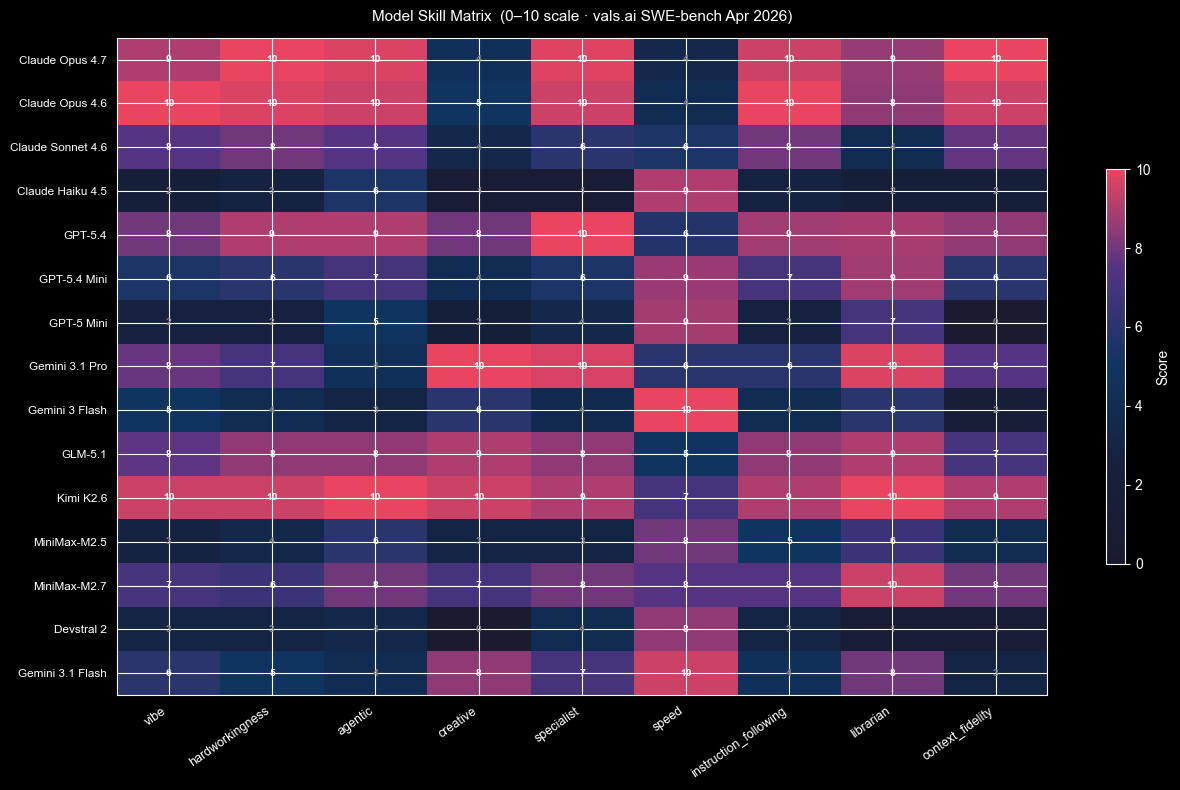

Saved skill_matrix.png


In [21]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
except ImportError:
    print("matplotlib not installed — run: pip install matplotlib")
    raise

skill_names = list(_raw_data["skills"].keys())
model_labels = [m.display_name for m in MODELS.values()]
model_keys   = list(MODELS.keys())

matrix = np.zeros((len(model_keys), len(skill_names)))
for i, mk in enumerate(model_keys):
    m = MODELS[mk]
    for j, sk in enumerate(skill_names):
        matrix[i, j] = m.skills.get(sk, 0)

fig, ax = plt.subplots(figsize=(13, 8))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "skill", ["#1a1a2e", "#16213e", "#0f3460", "#533483", "#e94560"], N=256
)
im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=10, aspect="auto")

ax.set_xticks(range(len(skill_names)))
ax.set_xticklabels(skill_names, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels, fontsize=8.5)

for i in range(len(model_keys)):
    for j in range(len(skill_names)):
        val = matrix[i, j]
        ax.text(j, i, f"{val:.0f}" if val else "—",
                ha="center", va="center",
                color="white" if val >= 5 else "#888", fontsize=7.5, fontweight="bold")

ax.set_title("Model Skill Matrix  (0–10 scale · vals.ai SWE-bench Apr 2026)",
             fontsize=11, pad=12)
plt.colorbar(im, ax=ax, label="Score", shrink=0.6)
plt.tight_layout()
plt.savefig("skill_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved skill_matrix.png")